# Lab 3: Building Custom Datasets

In this lab, we will build a custom Dataset class from scratch to understand how PyTorch loads data.

## Learning Objectives

By the end of this lab, you will be able to:
- Understand when and why to create custom Dataset classes
- Implement the three essential methods: `__init__`, `__len__`, `__getitem__`
- Build a dataset that replicates `ImageFolder` functionality
- Compare custom datasets with built-in alternatives

## 0. Setup

In [ ]:
import torch
import os
import pathlib
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import random
from typing import Tuple, Dict, List

device = 'cuda' if torch.cuda.is_available() else 'cpu'       # যদি GPU (CUDA) available থাকে → "cuda" না থাকলে → "cpu" 👉 GPU অনেক দ্রুত training করতে পারে
print(f'Using device: {device}')

Using device: cpu


In [ ]:
import requests
import zipfile
from pathlib import Path

data_path = Path('data/')
image_path = data_path / 'pizza_steak_sushi'

if image_path.is_dir():                                 # 👉 যদি folder already থাকে → download করবে না
    print(f'{image_path} directory exists.')
else:
    print(f'Creating {image_path} directory...')
    image_path.mkdir(parents=True, exist_ok=True)                           # 👉 নতুন folder create করে
    with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:              # 👉 zip file save করার জন্য file open
                                                                            # 👉 এখানে 'wb' হলো file mode
                                                                              # 🔸 Breakdown:
                                                                              # 'w' = write (লিখার জন্য open করা)
                                                                              # 'b' = binary (binary data হিসেবে)
                                                                              # 👉 তাই 'wb' = write binary
                                                                              # 🔹 কেন binary mode দরকার?
                                                                              # 👉 তুমি যেটা download করছো সেটা একটা .zip file
                                                                              # 👉 zip, image, video — এগুলো binary file
                                                                              # 📌 তাই:
                                                                              # text mode ('w') দিলে file corrupt হতে পারে ❌
                                                                              # binary mode ('wb') দিলে ঠিকভাবে save হয় ✔️
        request = requests.get('https://raw.githubusercontent.com/poridhioss/Introduction-to-Deep-Learning-with-Pytorch-Resources/main/Custom-Datasets/pizza_steak_sushi.zip')  # 👉 internet থেকে dataset download
        print('Downloading data...')
        f.write(request.content)
    with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:         # 👉 zip file খুলে সব data extract করে
        print('Unzipping data...')
        zip_ref.extractall(image_path)
    print('Done!')

train_dir = image_path / 'train'
test_dir = image_path / 'test'

print(f'Train dir: {train_dir}')
print(f'Test dir: {test_dir}')

Creating data/pizza_steak_sushi directory...
Unzipping data...
Done!
Train dir: data/pizza_steak_sushi/train
Test dir: data/pizza_steak_sushi/test


## 1. Helper Function: Find Classes

Before building our custom dataset, we need a helper function to discover classes from the directory structure.

### What This Function Does:

1. **Scans a directory** for subdirectories (each subdirectory = one class)
2. **Creates a mapping** from class names to integer indices
3. **Returns both** the class list and the mapping dictionary

### Implementation Details:

We'll use `os.scandir()` to traverse the target directory (which should be in standard image classification format):
- Get the class names by finding all subdirectories
- Raise an error if no class folders are found
- Turn the class names into a dictionary of numerical labels

**Important:** This mimics what `ImageFolder` does internally!

In [ ]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

    if not classes:
        raise FileNotFoundError(f'No class folders found in {directory}')

    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

এই function টা **dataset থেকে automatically class (label) খুঁজে বের করে এবং number assign করে**। সহজভাবে লাইন ধরে বুঝাই 👇

---

## 🔹 Function overview

```python
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
```

👉 Input: একটা folder path (directory)
👉 Output:

* class names list
* class → index mapping

---

## 🔸 Step 1: Class খুঁজে বের করা

```python
classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
```

👉 এখানে কী হচ্ছে:

* `os.scandir(directory)` → folder এর ভিতরের সব file/folder পড়ে
* `if entry.is_dir()` → শুধু folder নেয় (files বাদ)
* `entry.name` → folder নাম নেয় (যেমন: pizza, steak)

👉 তারপর:

* `sorted(...)` → alphabetically sort করে

📌 Example:

```python
pizza, sushi, steak → sorted → pizza, steak, sushi
```

---

## 🔸 Step 2: Empty check

```python
if not classes:
    raise FileNotFoundError(...)
```

👉 যদি কোনো class folder না থাকে → error দিবে

✔️ কারণ dataset invalid

---

## 🔸 Step 3: Class → Index mapping

```python
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
```

👉 এখানে dictionary বানানো হচ্ছে:

* `enumerate(classes)` → index দেয় (0,1,2...)

📌 Example:

```python
classes = ['pizza', 'steak', 'sushi']

class_to_idx = {
  'pizza': 0,
  'steak': 1,
  'sushi': 2
}
```

---

## 🔸 Step 4: Return

```python
return classes, class_to_idx
```

👉 দুইটা জিনিস return করে:

* class list
* mapping dictionary



In [ ]:
# Test the function
classes, class_to_idx = find_classes(train_dir)
print(f'Classes: {classes}')
print(f'Class to idx: {class_to_idx}')

Classes: ['pizza', 'steak', 'sushi']
Class to idx: {'pizza': 0, 'steak': 1, 'sushi': 2}


### Function Works Correctly! ✅

Our `find_classes()` function successfully:
- Found all 3 classes in alphabetical order
- Created the correct index mapping (pizza→0, steak→1, sushi→2)
- Matches the behavior of PyTorch's `ImageFolder`

## 2. Build Custom Dataset Class

Now we're ready to build our own custom Dataset.

### Why Build Custom Datasets?

While `ImageFolder` works for standard image classification, you might need custom datasets when:
- Your data has a **non-standard format** (CSV annotations, JSON metadata)
- You need **custom preprocessing** or **complex augmentations**
- You're working with **multiple data sources** (images + text + tabular)
- Your labels are stored **separately** from images

### The Three Essential Methods

Every PyTorch Dataset must implement:

| Method | Purpose |
|--------|---------|
| `__init__(self, ...)` | Initialize paths, transforms, load metadata |
| `__len__(self)` | Return total number of samples |
| `__getitem__(self, idx)` | Return one sample (image, label) given an index |

চলো সহজভাবে বুঝি — **“Why Build Custom Datasets?”** 👇

---

## 🧠 আগে বুঝো: `ImageFolder` কী করে?

ImageFolder automatically ধরে নেয়:

```
data/
 ├── cat/
 ├── dog/
```

👉 Folder name = label
👉 Image inside = data

✔ Simple classification-এর জন্য perfect
❌ কিন্তু real-world data এভাবে থাকে না

---

# 🔥 তাহলে Custom Dataset কেন দরকার?

## 1️⃣ Non-standard data format

👉 অনেক সময় label folder-এ থাকে না

### Example:

CSV file:

```
image_name,label
img1.jpg,cat
img2.jpg,dog
```

👉 এখানে label আলাদা file-এ
👉 `ImageFolder` এটা বুঝতে পারবে না

✔ তাই custom dataset লাগবে

---

## 2️⃣ Custom preprocessing / augmentation

👉 ধরো তুমি চাইছো:

* specific crop
* grayscale + blur
* multiple transformations

👉 `ImageFolder` basic transform দেয়
❌ complex logic handle করতে পারে না

✔ Custom dataset = full control

---

## 3️⃣ Multiple data sources

👉 Real ML project example:

* image + text + numeric data

```
image → X-ray
text → doctor note
tabular → age, weight
```

👉 `ImageFolder` শুধু image নেয়
❌ multi-modal data support নাই

✔ Custom dataset দিয়ে সব combine করা যায়

---

## 4️⃣ Labels stored separately

👉 অনেক dataset এ:

* images এক folderে
* labels অন্য file (JSON/CSV)

### Example (JSON):

```json
{
  "img1.jpg": "cat",
  "img2.jpg": "dog"
}
```

👉 Again, `ImageFolder` useless এখানে

✔ Custom dataset = manually load labels



In [ ]:
class ImageFolderCustom(Dataset):

    def __init__(self, targ_dir: str, transform=None) -> None:
        # targ_dir থেকে সব .jpg image path collect করা হচ্ছে (subfolder সহ)
        self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))

        # optional transform (augmentation / preprocessing)
        self.transform = transform

        # class name এবং index mapping তৈরি করা হচ্ছে
        self.classes, self.class_to_idx = find_classes(targ_dir)

    def load_image(self, index: int) -> Image.Image:
        # নির্দিষ্ট index অনুযায়ী image path নেওয়া হচ্ছে
        image_path = self.paths[index]

        # image open করে return করা হচ্ছে
        return Image.open(image_path)

    def __len__(self) -> int:
        # dataset এ মোট কয়টা image আছে তা return করে
        return len(self.paths)

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        # নির্দিষ্ট index এর image load করা হচ্ছে
        img = self.load_image(index)

        # image যে folder এ আছে সেই folder name = class name
        class_name = self.paths[index].parent.name

        # class name থেকে numeric label (index) বের করা হচ্ছে
        class_idx = self.class_to_idx[class_name]

        # যদি transform দেওয়া থাকে তাহলে apply করা হবে
        if self.transform:
            return self.transform(img), class_idx
        else:
            # না থাকলে raw image return করবে
            return img, class_idx

### Understanding the Implementation

Let's break down each part of our custom dataset:

**1. Subclass `torch.utils.data.Dataset`**
- Inherit from PyTorch's base Dataset class

**2. `__init__` Method**
- `targ_dir`: Target directory containing the images
- `transform`: Optional transforms to apply to images
- `self.paths`: List of all image file paths using `pathlib.Path.glob()`
- `self.classes` & `self.class_to_idx`: From our `find_classes()` function

**3. `load_image` Method**
- Helper method to load images from file using PIL
- Returns a PIL Image object
- Separated for clarity and potential customization

**4. `__len__` Method (Required)**
- Overrides the Dataset's `__len__` method
- Returns the number of samples in the dataset
- Allows calling `len(dataset)`

**5. `__getitem__` Method (Required)**
- Overrides the Dataset's `__getitem__` method
- Loads the image at the given index
- Extracts class name from the file path
- Converts class name to integer index
- Applies transforms if provided
- Returns tuple: `(transformed_image, class_index)`


চলো step-by-step একদম clearভাবে বুঝি 👇
তুমি basically একটা **custom dataset pipeline** বানাচ্ছো (PyTorch-এ)

---

# 🧠 1️⃣ Subclass `torch.utils.data.Dataset`

👉 তুমি লিখেছো:

```python
class ImageFolderCustom(Dataset):
```

✔ এখানে তুমি PyTorch এর `Dataset` class inherit করছো

👉 মানে:

* PyTorch কে বলছো: “এই class টা dataset হিসেবে use করো”

📌 Rule:
👉 Custom dataset বানাতে হলে **এই base class inherit করতেই হবে**

---

# ⚙️ 2️⃣ `__init__` Method (Setup Phase)

👉 এটা dataset তৈরি করার সময় একবার run হয়

### এখানে কী হচ্ছে?

* `targ_dir` → image folder path
* `transform` → image modify করার function

```python
self.paths = list(pathlib.Path(targ_dir).glob('*/*.jpg'))
```

👉 সব image path collect করছে
👉 ধরো:

```
data/cat/img1.jpg
data/dog/img2.jpg
```

---

```python
self.classes, self.class_to_idx = find_classes(targ_dir)
```

👉 class name + index mapping বানাচ্ছে

```
cat → 0
dog → 1
```

✔ Model numeric label চায়, তাই এটা দরকার

---

# 🖼️ 3️⃣ `load_image` Method

👉 এটা helper function (optional কিন্তু clean code)

```python
return Image.open(image_path)
```

✔ এখানে PIL ব্যবহার করে image load হচ্ছে

👉 আলাদা method রাখার সুবিধা:

* future এ customize করতে পারবে
* code clean থাকে

---

# 📏 4️⃣ `__len__` Method (Mandatory)

```python
return len(self.paths)
```

👉 Dataset এ কয়টা image আছে সেটা return করে

✔ এটা দরকার কারণ:

```python
len(dataset)
```

call করলে total sample জানতে পারবে

---

# 🎯 5️⃣ `__getitem__` Method (MOST IMPORTANT)

👉 এই function-টাই আসল কাজ করে
👉 PyTorch বারবার এটা call করে data load করে

---

## Step-by-step:

### 🔹 Step 1: Image load

```python
img = self.load_image(index)
```

---

### 🔹 Step 2: Class name বের করা

```python
class_name = self.paths[index].parent.name
```

👉 Example:

```
data/cat/img1.jpg → class = "cat"
```

---

### 🔹 Step 3: Numeric label বানানো

```python
class_idx = self.class_to_idx[class_name]
```

👉 Output:

```
cat → 0
dog → 1
```

---

### 🔹 Step 4: Transform apply (if exists)

```python
if self.transform:
    return self.transform(img), class_idx
```

👉 Example transform:

* resize
* tensor convert
* normalization

---

### 🔹 Step 5: Final Output

```python
return (image, label)
```

✔ Model training এ এই format লাগে:

```
(X, y)
```



## 3. Create Custom Datasets

Now let's instantiate our custom dataset class with proper transforms.

### Defining Transforms

Before testing our `ImageFolderCustom` class, we need to create transforms to prepare our images.

**Critical Distinction:**

| Transform Set | Augmentation | Purpose |
|---------------|--------------|---------|
| **Training** | ✅ `RandomHorizontalFlip(p=0.5)` | Improve generalization |
| **Testing** | ❌ No augmentation | Consistent, fair evaluation |

**Why no augmentation for testing?**
- Test set should represent real-world conditions
- Augmentation adds randomness that makes evaluation inconsistent
- We want reproducible results for benchmarking

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

### Instantiate Datasets

Now let's create `Dataset` objects for both training and testing images using our `ImageFolderCustom` class:

In [ ]:
train_data_custom = ImageFolderCustom(
    targ_dir=train_dir,
    transform=train_transforms
)

test_data_custom = ImageFolderCustom(
    targ_dir=test_dir,
    transform=test_transforms
)

print(f'Train samples: {len(train_data_custom)}')
print(f'Test samples: {len(test_data_custom)}')
print(f'Classes: {train_data_custom.classes}')
print(f'Class_to_idx: {train_data_custom.class_to_idx}')

Train samples: 225
Test samples: 75
Classes: ['pizza', 'steak', 'sushi']
Class_to_idx: {'pizza': 0, 'steak': 1, 'sushi': 2}


In [ ]:
img, label = train_data_custom[0]
print(f'Image shape: {img.shape}')
print(f'Label: {label} ({train_data_custom.classes[label]})')

Image shape: torch.Size([3, 64, 64])
Label: 1 (steak)


### Dataset Created Successfully! ✅

Perfect! Our custom dataset:
- Returns tensors with correct shape `[3, 64, 64]`
- Provides integer labels (0, 1, or 2)
- Can be indexed like a Python list
- Works exactly like PyTorch's built-in datasets

## 4. Compare with ImageFolder

Let's verify our custom dataset produces the same results as PyTorch's built-in `ImageFolder`.

### Verification Checklist:

| Property | Should Match |
|----------|--------------|
| Number of samples | `len(dataset)` |
| Class names | `dataset.classes` |
| Class indices | `dataset.class_to_idx` |
| Sample format | `(tensor, label)` tuple |

**Why this comparison matters:**
- Ensures our implementation is correct
- Validates that we understand how `ImageFolder` works internally
- Confirms our dataset can be used as a drop-in replacement

In [ ]:
train_data_imagefolder = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

print(f'Custom length: {len(train_data_custom)}')
print(f'ImageFolder length: {len(train_data_imagefolder)}')
print(f'Custom classes: {train_data_custom.classes}')
print(f'ImageFolder classes: {train_data_imagefolder.classes}')

Custom length: 225
ImageFolder length: 225
Custom classes: ['pizza', 'steak', 'sushi']
ImageFolder classes: ['pizza', 'steak', 'sushi']


## 5. Create DataLoaders

Custom datasets work seamlessly with `DataLoader` - this is the power of PyTorch's modular design!

### The Beauty of PyTorch's Design

The `DataLoader` doesn't care whether you're using:
- Built-in datasets (`ImageFolder`, `MNIST`, `CIFAR10`)
- Custom datasets (like our `ImageFolderCustom`)
- Any class that implements `__len__` and `__getitem__`

**As long as your dataset implements the required methods correctly, everything just works!**

### Why This Matters:

1. **Modularity** - Swap datasets without changing training code
2. **Consistency** - Same DataLoader API for all datasets
3. **Flexibility** - Build custom datasets for any use case
4. **Integration** - Works with all PyTorch training loops

চলো এই অংশটা একদম সহজভাবে বুঝি 👇

---

# 🧠 5️⃣ Create DataLoaders — কী হচ্ছে এখানে?

👉 তুমি **dataset → DataLoader** এ convert করছো যাতে training সহজ হয়

```python id="d4c9z1"
from torch.utils.data import DataLoader
```

---

# 🔥 Core Idea

👉 তুমি যেকোনো dataset use করো:

* Built-in dataset (ImageFolder, MNIST)
* Custom dataset (তোমার `ImageFolderCustom`)

✔ **DataLoader সবকিছুর সাথে কাজ করে**

---

# 🧠 কেন কাজ করে?

👉 কারণ PyTorch DataLoader শুধু এই 2টা method চায়:

✔ `__len__()` → dataset size
✔ `__getitem__()` → sample return

👉 তোমার custom dataset এগুলো already implement করেছে ✅

---

# ⚙️ DataLoader কী করে?

👉 DataLoader dataset কে:

* batches-এ ভাগ করে
* shuffle করে
* parallel loading করে

---

# 📦 Example Code

```python id="q7v9z2"
train_loader = DataLoader(
    train_data_custom,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_data_custom,
    batch_size=32,
    shuffle=False
)
```

---

# 🔍 Parameters বোঝা

### 🔹 `batch_size=32`

👉 একবারে 32টা sample নেবে

✔ training fast হয়
✔ GPU efficient হয়

---

### 🔹 `shuffle=True` (Train only)

👉 data random order এ দেয়

✔ model better generalize করে
✔ overfitting কমে

---

### 🔹 `shuffle=False` (Test)

👉 order same থাকে

✔ consistent evaluation

---

# 🔁 Internally কী হয়?

👉 যখন তুমি loop চালাও:

```python id="x9m8ab"
for images, labels in train_loader:
```

👉 DataLoader internally:

1. dataset থেকে `__getitem__` call করে
2. batch বানায়
3. tuple return করে

---

# 🎯 Why This Matters (Key Concept)

## ✅ 1. Modularity

👉 dataset change করলেও training code same থাকে

```python id="t3kqf2"
train_loader = DataLoader(new_dataset, ...)
```

✔ training loop unchanged

---

## ✅ 2. Consistency

👉 সব dataset একই API follow করে

✔ PyTorch ecosystem uniform

---

## ✅ 3. Flexibility

👉 তুমি:

* image dataset
* text dataset
* multi-modal dataset

সব use করতে পারো

✔ same DataLoader

---

## ✅ 4. Integration

👉 Works directly with training loop:

```python id="r2m0z1"
for epoch in range(epochs):
    for X, y in train_loader:
        # forward pass
        # loss
        # backward
```

In [ ]:
BATCH_SIZE = 32

train_dataloader_custom = DataLoader(
    dataset=train_data_custom,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

test_dataloader_custom = DataLoader(
    dataset=test_data_custom,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_dataloader_custom))
print(f'Batch shape: {images.shape}')
print(f'Labels shape: {labels.shape}')

Batch shape: torch.Size([32, 3, 64, 64])
Labels shape: torch.Size([32])


## 6. Visualize Custom Dataset

Let's verify our custom dataset returns properly formatted images by visualizing a random sample.

**What we're checking:**
- Images display correctly (no corruption)
- Transforms are applied properly (64×64 size)
- Labels match the images
- Random sampling works as expected

In [ ]:
def display_random_images(dataset, classes, n=6, seed=42):
    random.seed(seed)
    random_idx = random.sample(range(len(dataset)), k=n)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i, idx in enumerate(random_idx):
        img, label = dataset[idx]
        ax = axes[i // 3, i % 3]
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(f'{classes[label]}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

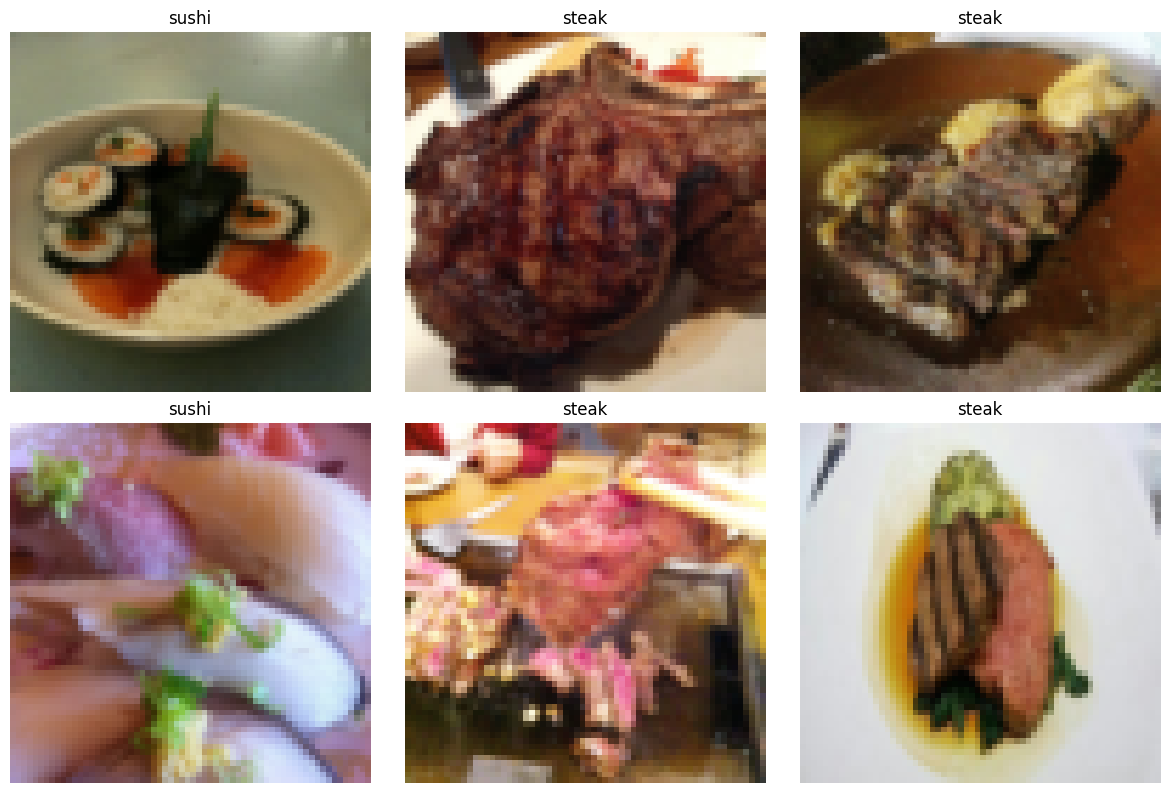

In [ ]:
display_random_images(train_data_custom, train_data_custom.classes)

### Custom Dataset Working Perfectly! 🎉

Excellent! Our `ImageFolderCustom` dataset is working exactly as expected:
- Images are loaded correctly from disk
- Transforms are applied (Resize, RandomFlip, ToTensor)
- Labels match the visual content
- Ready for training with DataLoader

We've successfully built a custom dataset from scratch!

## Key Takeaways

### The Three Essential Methods

| Method | Purpose | Implementation |
|--------|---------|----------------|
| **`__init__`** | Setup: store paths, find classes, define transforms | Initialize all attributes |
| **`__len__`** | Return `len(self.paths)` - total samples | Enable `len(dataset)` |
| **`__getitem__`** | Load image, apply transform, return (tensor, label) | Enable indexing `dataset[i]` |

### What We Learned

1. **Custom Dataset Structure** - How to subclass `torch.utils.data.Dataset`
2. **Helper Functions** - Using `find_classes()` to discover labels
3. **Transform Separation** - Different transforms for train/test
4. **DataLoader Integration** - Custom datasets work seamlessly
5. **Verification** - Comparing with built-in `ImageFolder`

### When to Use Custom vs ImageFolder

| Use Case | Recommendation | Reason |
|----------|----------------|--------|
| Standard image classification folders | `ImageFolder` | Fast, tested, optimized |
| Annotations in CSV/JSON | Custom Dataset | Need custom label parsing |
| Multiple input types (image + text) | Custom Dataset | Flexible data handling |
| Complex preprocessing pipeline | Custom Dataset | Full control over loading |
| Learning PyTorch internals | Custom Dataset | Educational value |

### Custom Dataset Advantages

✅ **Complete control** over data loading process  
✅ **Flexible** - handle any data format or structure  
✅ **Customizable** - add special preprocessing logic  
✅ **Educational** - understand PyTorch internals  

### What's Next?

In **Lab 4**, we'll build and train a **TinyVGG** convolutional neural network using our complete data pipeline!

**The full workflow:**
```
Custom Dataset → DataLoader → TinyVGG Model → Training → Evaluation
```

---

**Remember:** The power of custom datasets is flexibility. While `ImageFolder` is great for standard use cases, custom datasets unlock PyTorch's full potential for complex data scenarios!